In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import argparse
import numpy as np
from run_vmc import main
import os

def check_info(step, log, driver, save_path):
    if not isinstance(driver.info, dict):
        status = int(driver.info)
        if status != 0:
            print(f"Solver returned error status: {status}")
            np.save(save_path + "error_local_energies.npy", driver.state.local_estimators(driver._ham))
            print("Local energies saved...")
            return False
        else:
            return True
    return True

chunk_size = -1 - momentum = False
chunk_size = -1 - momentum = False


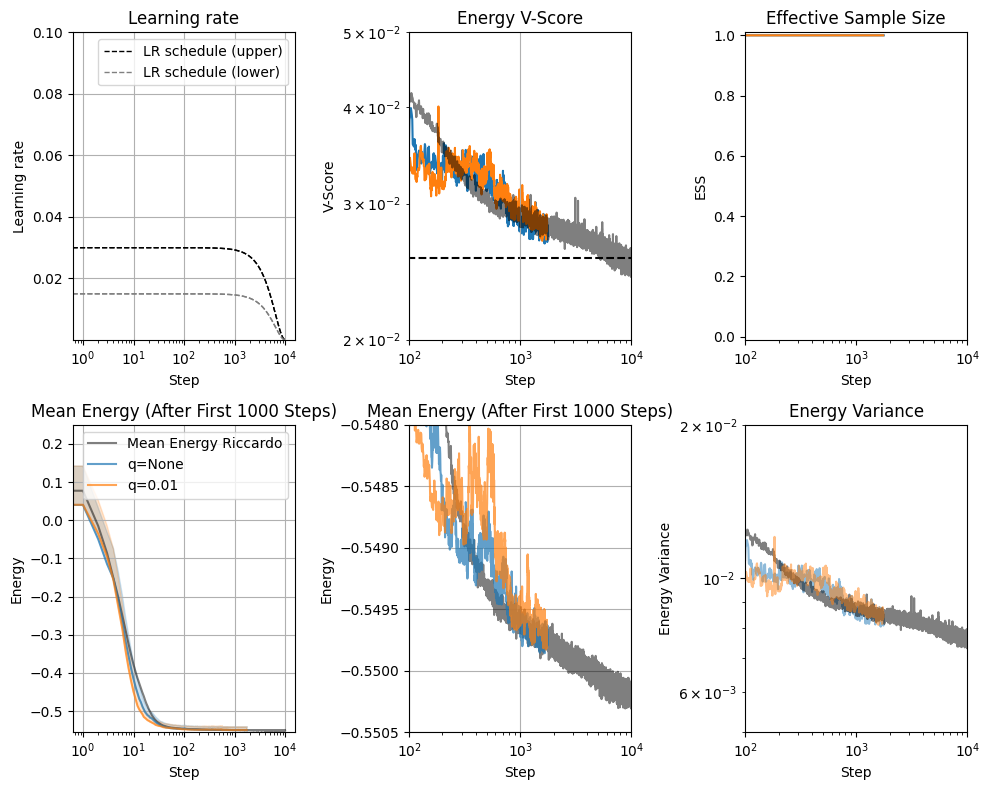

In [49]:
# Create figure with 3 subplots
fig, axs = plt.subplots(2, 3)
fig.set_size_inches(10, 8)
# CSs = [-1, -1, 8192, 2048]
num_layers = 2
x_min = 100
for i, q in enumerate([None, 0.01, ]):
    
    # Configuration dictionary
    ns = 2**14
    config = {
        "ns": ns,
        "patch_size": 3,
        "num_layers": num_layers,
        "d_model": 72,
        "heads": 12,
        "L": 12,
        "seed": 100,
        "experiment_name": "Mar24",
        "diag_shift": 1e-4,
        "lr": 0.03,
        "thermalizing_steps": 0,
        "chunk_size": -1,
        "auto_tune_lr": False,
        "q_blur": q,
    }

    # Convert to namespace for compatibility with get_data
    args = argparse.Namespace(**config)
    logger, experiment_config = main(args, return_logger=True)
    if not logger.restore():
        continue
    # Extract energy data
    L = config["L"]
    N = L**2
    internal_lrs = np.array(logger.data["internal_lr"]["values"])
    energies_mean = np.array(logger.data["Energy"]["Mean"]).real / N
    energies_variance = np.array(logger.data["Energy"]["Variance"]).real / N
    energies_w_variance = np.array(logger.data["weighted_variance"]["values"]).real / N
    try:
        ess_values = np.array(logger.data["ess"]["values"])
    except KeyError:
        ess_values = np.array([np.nan])

    try:
        accept_values = np.array(logger.data["acceptance"]["values"])
    except KeyError:
        accept_values = np.array([np.nan])

    energies_w_variance = np.array(logger.data["weighted_variance"]["values"]).real / N
    if not energies_w_variance.size:
        energies_w_variance = energies_variance

    # Calculate standard error from variance
    std_error = np.sqrt(energies_variance / N)

    # Plot 1: Mean energy (full trajectory)
    # Load loss data from loss.txt
    energies_mean_riccardo = np.loadtxt(f"loss_{num_layers}.txt")
    energies_variance_riccardo = np.loadtxt(f"variance_per_site_{num_layers}.txt")
    lr_schedule = experiment_config.optimizer.build_lr()
    axs[0, 0].plot(internal_lrs, label=f"q={q}")
    steps = np.arange(10000)
    (upper_lr_line,) = axs[0, 0].plot(
        steps,
        lr_schedule(steps),
        color="black",
        linewidth=1,
        linestyle="--",
        label="LR schedule (upper)",
    )
    (lower_lr_line,) = axs[0, 0].plot(
        steps,
        np.array(lr_schedule(steps)) / 2,
        color="gray",
        linewidth=1,
        linestyle="--",
        label="LR schedule (lower)",
    )
    axs[0, 0].set_xlabel("Step")
    axs[0, 0].set_ylabel("Learning rate")
    axs[0, 0].set_title("Learning rate")
    axs[0, 0].legend(handles=[upper_lr_line, lower_lr_line], loc="best")
    axs[0, 0].set_xscale("log")
    axs[0, 0].set_ylim([1e-4, 1e-1])
    axs[0, 0].grid(True)
    # Variance
    if i == 0:
        axs[0, 1].plot(
            energies_variance_riccardo / energies_mean_riccardo**2,
            label="V-score Riccardo",
            color="black",
            alpha=0.5,
        )
        axs[0, 1].hlines(
            energies_variance_riccardo[-1] / energies_mean_riccardo[-1] ** 2,
            0,
            len(energies_variance_riccardo),
            color="black",
            linestyle="dashed",
            zorder=1,
        )
        # axs[0,1].plot(energies_variance_riccardo, label="V-score Riccardo", color="black")
        # axs[0,1].hlines( energies_variance_riccardo[-1]/energies_mean_riccardo[-1]**2,0,len(energies_variance_riccardo), color="black", linestyle='dashed', zorder=1)

    axs[0, 1].plot(energies_w_variance / energies_mean**2, label=f"q={q}", zorder=-1)
    # axs[0,1].plot(energies_variance, label=f"q={q}", zorder=-1)
    axs[0, 1].set_xlabel("Step")

    axs[0, 1].set_ylabel("V-Score")
    axs[0, 1].set_title("Energy V-Score")
    # axs[0, 1].legend()
    axs[0, 1].set_yscale("log")
    axs[0, 1].set_xscale("log")
    axs[0, 1].set_xlim(x_min, 10000)
    axs[0, 1].set_ylim(2e-2, 5e-2)
    axs[0, 1].grid(True)
    # Plot 2: Mean energy after first 1000 steps
    for k, ax in enumerate([axs[1, 0], axs[1, 1]]):
        if i == 0:
            ax.plot(
                energies_mean_riccardo,
                label="Mean Energy Riccardo",
                alpha=0.5,
                color="black",
            )
        line = ax.plot(energies_mean, label=f"q={q}", alpha=0.7)[0]

        # Add band for mean + std error (not negative)
        if k == 0:
            ax.fill_between(
                np.arange(len(energies_mean)),
                energies_mean,
                energies_mean + std_error,
                color=line.get_color(),
                alpha=0.2,
            )

        ax.set_xlabel("Step")
        if k == 0:
            ax.set_ylim(-0.555, 0.25)
        else:
            ax.set_ylim(-0.5505, -0.548)
            ax.set_xlim(x_min, 10000)
        ax.set_xscale("log")
        ax.set_ylabel("Energy")
        ax.set_title("Mean Energy (After First 1000 Steps)")
        # if k == 0:
        #     ax.legend()
        ax.grid(True)
    axs[1, 0].legend()
    axs[0, 2].plot(ess_values)
    axs[0, 2].set_xlabel("Step")
    axs[0, 2].set_xscale("log")
    axs[0, 2].set_ylabel(r"ESS")
    axs[0, 2].set_title("Effective Sample Size")
    axs[0, 2].set_ylim([-0.01, 1.01])
    axs[0, 2].set_xlim(x_min, 10000)

    axs[1, 2].plot(energies_w_variance, alpha=0.5)
    axs[1, 2].set_xlabel("Step")
    axs[1, 2].set_xscale("log")
    axs[1, 2].set_yscale("log")
    axs[1, 2].set_ylabel("Energy Variance")
    # axs[1, 2].set_ylim([-0.01, 1.01])
    axs[1, 2].set_title("Energy Variance")
    if i == 0:
        axs[1, 2].plot(
            energies_variance_riccardo,
            label="Variance Riccardo",
            color="black",
            alpha=0.5,
        )
    axs[1, 2].set_ylim(5e-3, 2e-2)
    axs[1, 2].set_xlim(x_min, 10000)

fig_path = "./figures/" + logger.path + "/"
plt.tight_layout()
if not os.path.exists(fig_path):
    os.makedirs(fig_path)
plt.savefig(fig_path + "run.pdf")
plt.show()